# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais et angle d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération et de gyroscopie_
_Date : 2026-04-03_
---


## 2. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [12]:
# import math
import numpy as np
import matplotlib.pyplot as plt

from Test_Kalman_4 import Test_Kalman_4_fns as tk

## 3. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [13]:
# Paramètres globaux

tk.TotalTime = 100
tk.SampleSize = 1000  # nombre d'instants de mesure  # <<<
tk.TimeStep = float(tk.TotalTime / tk.SampleSize)  # période d'échantillonage (s)  # <<<

RandomSeed = 123
np.random.seed(RandomSeed)

# Paramètres du modèle de mouvement  # <<<

tk.TrueInitialAlpha = 0.0  # angle initial vrai (°)        # <<<
tk.TrueInitialAlphadot = 0.0  # vitesse angulaire initiale vraie (°/s)        # <<<
tk.TrueInitialBias = 20.0  # biais de vitesse angulaire vrai (°/s)             # <<<

tk.SupposedInitialAlpha = 0.0  # angle initial vrai (°)        # <<<
tk.SupposedInitialAlphadot = 0.0  # vitesse angulaire initiale vraie (°/s)        # <<<
tk.SupposedInitialBias = 0.0  # biais de vitesse angulaire vrai (°/s)             # <<<

tk.MeasurementAlphaNoiseStd = 10.0  # => R écart-type du bruit de mesure sur alpha  # <<<
tk.MeasurementAlphadotNoiseStd = 5.0  # => R écart-type du bruit de mesure sur alphadot   # <<<

tk.ProcessAlphaNoiseStd = 0.1  # => Q bruit de processus (sur alpha)  # <<<
tk.ProcessAlphadotNoiseStd = 1  # => Q bruit de processus (sur alphadot)  # <<<
tk.ProcessBiasNoiseStd = .0005  # => Q bruit de processus (sur bias)  # <<<

tk.ProcessInitialConfidenceStd = 1000  # => Q bruit de processus (sur alpha)  # <<<


## 4. Définition des fonctions principales

Regrouper ici les fonctions réutilisables pour le traitement.

## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [14]:
# Génération du comportement vrai et des mesures bruitées
(TimeArray,
 TrueAlphaArray,
 TrueAlphadotArray,
 MeasuredAlphaArray,
 MeasuredAlphadotArray) = tk.GenerateTrueValuesAndMeasurements()

TimeStep : 0.1
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
currentAlphadotdot: 0.0
c

In [15]:
# Création et configuration du filtre de Kalman
KF = tk.CreateKalmanFilter()

In [16]:
# Création et configuration du filtre de Kalman
UKF = tk.CreateUnscentedKalmanFilter()

In [17]:
# Génération du comportement vrai et des mesures bruitées
# Application du filtre sur toutes les mesures
(EstimatedAlphaArray,
 EstimatedAlphadotArray,
 EstimatedBiasArray) = tk.ApplyKalmanFilterOnMeasurements(
    KF,
    MeasuredAlphaArray,
    MeasuredAlphadotArray
)

print("FirstTrueAlpha     =", TrueAlphaArray[0])
print("FirstMeasuredAlpha =", MeasuredAlphaArray[0])
print("FirstEstimatedAlpha =", EstimatedAlphaArray[0])
print("FirstTrueAlphadot     =", TrueAlphadotArray[0])
print("FirstEstimatedAlphadot =", EstimatedAlphadotArray[0])

FirstTrueAlpha     = 0.0
FirstMeasuredAlpha = -10.856306033005612
FirstEstimatedAlpha = -10.855145045270092
FirstTrueAlphadot     = 0.0
FirstEstimatedAlphadot = 7.547332968571468


In [18]:
# Génération du comportement vrai et des mesures bruitées
# Application du filtre sur toutes les mesures
(EstimatedAlphaArrayU,
 EstimatedAlphadotArrayU,
 EstimatedBiasArrayU) = tk.ApplyUnscentedKalmanFilterOnMeasurements(
    UKF,
    MeasuredAlphaArray,
    MeasuredAlphadotArray
)

print("FirstTrueAlpha     =", TrueAlphaArray[0])
print("FirstMeasuredAlpha =", MeasuredAlphaArray[0])
print("FirstEstimatedAlphaU =", EstimatedAlphaArrayU[0])
print("FirstTrueAlphadot     =", TrueAlphadotArray[0])
print("FirstEstimatedAlphadotU =", EstimatedAlphadotArrayU[0])

FirstTrueAlpha     = 0.0
FirstMeasuredAlpha = -10.856306033005612
FirstEstimatedAlphaU = -10.855145045215222
FirstTrueAlphadot     = 0.0
FirstEstimatedAlphadotU = 7.547328586926265


## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

In [19]:
print(f"MeasurementAlphaNoiseStd = {tk.MeasurementAlphaNoiseStd}")
print(f"MeasurementAlphadotNoiseStd = {tk.MeasurementAlphadotNoiseStd}")
print(f"ProcessAlphaNoiseStd = {tk.ProcessAlphaNoiseStd}")
print(f"ProcessAlphadotNoiseStd = {tk.ProcessAlphadotNoiseStd}")
print(f"ProcessBiasNoiseStd = {tk.ProcessBiasNoiseStd}")

MeasurementAlphaNoiseStd = 10.0
MeasurementAlphadotNoiseStd = 5.0
ProcessAlphaNoiseStd = 0.1
ProcessAlphadotNoiseStd = 1
ProcessBiasNoiseStd = 0.0005


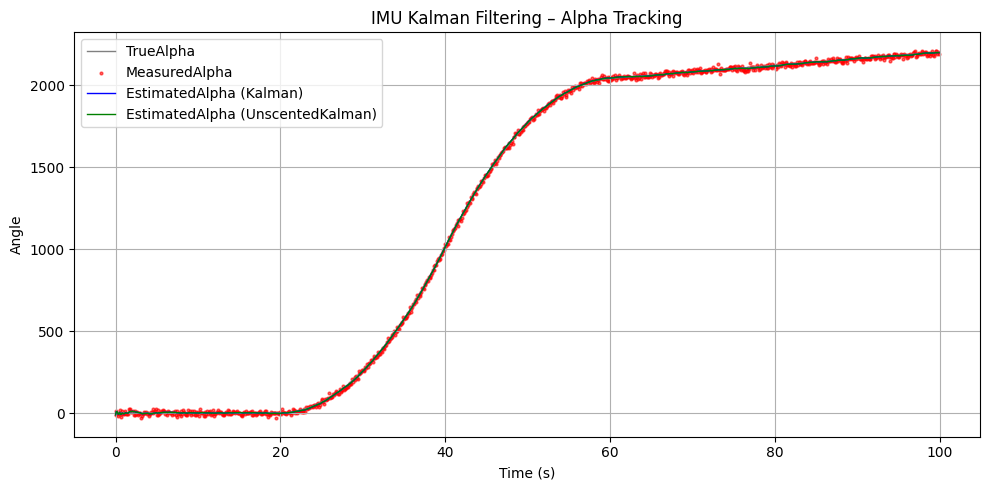

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(TimeArray,
         TrueAlphaArray,
         label="TrueAlpha",
         color="grey",
         linewidth=1)

plt.scatter(TimeArray,
            MeasuredAlphaArray,
            label="MeasuredAlpha",
            color="red",
            s=4,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphaArray,
         label="EstimatedAlpha (Kalman)",
         color="blue",
         linewidth=1)

plt.plot(TimeArray,
         EstimatedAlphaArrayU,
         label="EstimatedAlpha (UnscentedKalman)",
         color="green",
         linewidth=1)

plt.title("IMU Kalman Filtering – Alpha Tracking")
plt.xlabel("Time (s)")
plt.ylabel("Angle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

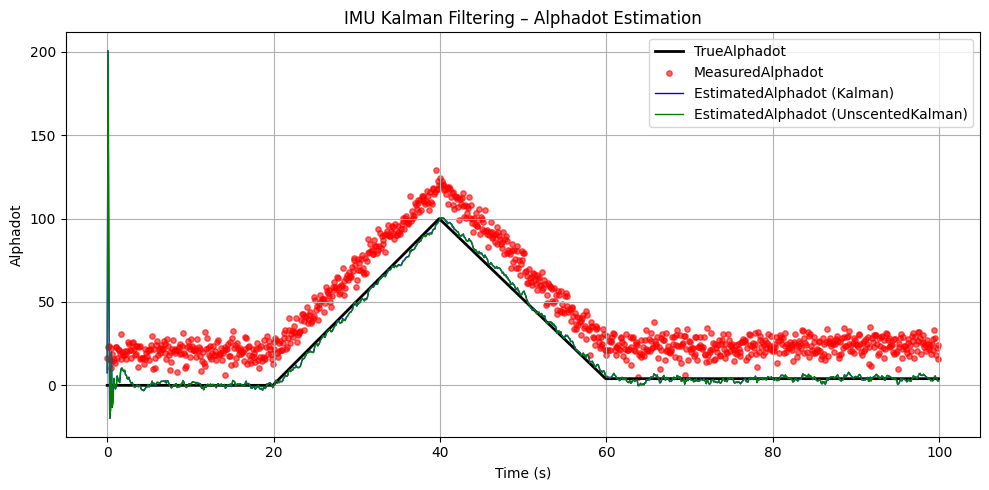

In [21]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         TrueAlphadotArray,
         label="TrueAlphadot",
         color="black",
         linewidth=2)  # <<<

plt.scatter(TimeArray,
            MeasuredAlphadotArray,
            label="MeasuredAlphadot",
            color="red",
            s=15,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphadotArray,
         label="EstimatedAlphadot (Kalman)",
         color="blue",
         linewidth=1)  # <<<

plt.plot(TimeArray,
         EstimatedAlphadotArrayU,
         label="EstimatedAlphadot (UnscentedKalman)",
         color="green",
         linewidth=1)  # <<<

plt.title("IMU Kalman Filtering – Alphadot Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Alphadot")  # <<<
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

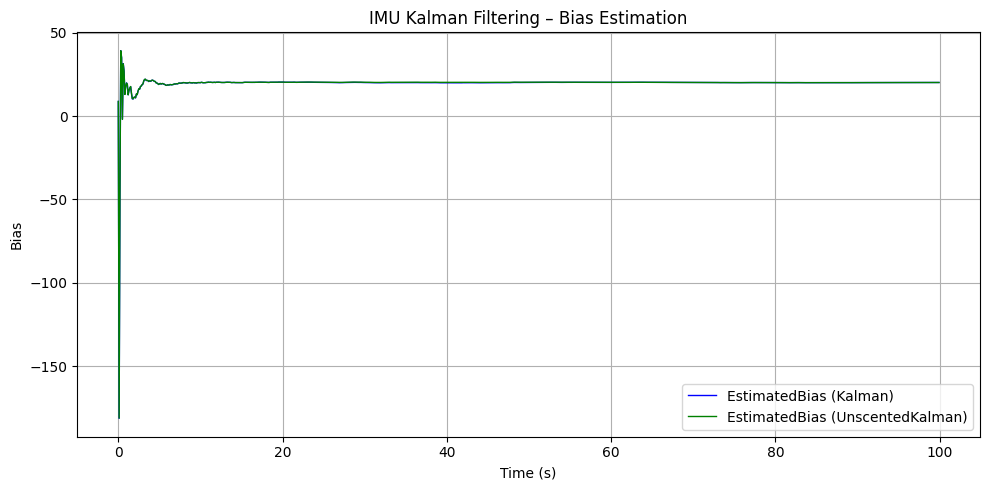

In [22]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         EstimatedBiasArray,
         label="EstimatedBias (Kalman)",
         color="blue",
         linewidth=1)  # <<<

plt.plot(TimeArray,
         EstimatedBiasArrayU,
         label="EstimatedBias (UnscentedKalman)",
         color="green",
         linewidth=1)  # <<<

plt.title("IMU Kalman Filtering – Bias Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Bias")  # <<<
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()